# Repeated Plateau Search Comparison

This notebook studies how the number of consecutive applications of `move_plateau` affects solution quality and runtime.

It produces two LaTeX tables:

1. mean relative solution quality after each application
2. mean cumulative runtime after each application

The analysis is grouped by graph type, size class, and density regime.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

## Configuration

In [2]:
MAX_STEPS = 10
REPEATED_PIPELINE = ",".join(["move_plateau"] * MAX_STEPS)
MOVE_STEPS = list(range(1, MAX_STEPS + 1))

GRAPH_ORDER = ["powerlaw", "er"]

DATASET_ORDER = [
    "small sparse",
    "small dense",
    "large sparse",
    "large dense",
]

GRAPH_TYPE_LABELS = {
    "powerlaw": "Powerlaw",
    "er": "Erdős–Rényi",
}

RESULTS_DIR = Path("../../results/experiment2/repeated_plateau_search")
STEP_RESULTS_FILE = RESULTS_DIR / "step_results.csv"

PLOTS_DIR = Path("../../results/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [3]:
steps = pd.read_csv(STEP_RESULTS_FILE)

steps["dataset_group"] = steps["size_class"].astype(str) + " " + steps["regime"].astype(str)

steps["graph_type"] = pd.Categorical(
    steps["graph_type"],
    categories=GRAPH_ORDER,
    ordered=True,
)

steps["dataset_group"] = pd.Categorical(
    steps["dataset_group"],
    categories=DATASET_ORDER,
    ordered=True,
)

steps = steps[(steps["pipeline"] == REPEATED_PIPELINE) & (steps["step_name"] == "move_plateau")].copy()

steps["step_number"] = steps["step_index"] + 1

## Solution quality

For every instance and application number, the best result across all randomized runs and start partitions is retained.

The result after ten applications is used as the reference. Relative solution quality after application $k$ is defined as

$
\frac{\text{score after application }10}
     {\text{score after application }k}.
$

A value of $1.0$ means that the result already matches the best result obtained after ten applications. Values greater than $1.0$ indicate the remaining quality gap.

In [4]:
best_run_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "step_number",
]

best_runs = (
    steps
    .sort_values(["score_after", "runtime", "run"], ascending=[False, True, True])
    .groupby(best_run_keys, observed=True, as_index=False)
    .head(1)
    .reset_index(drop=True)
)

In [5]:
instance_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
]

step_scores = best_runs.pivot(
    index=instance_keys,
    columns="step_number",
    values="score_after",
)

reference_score = step_scores[MAX_STEPS]
relative_quality = step_scores.rdiv(reference_score, axis=0)

relative_quality.columns.name = "step_number"

relative_quality_summary = (
    relative_quality
    .groupby(level=["graph_type", "dataset_group"])
    .mean()
    .stack()
    .rename("mean_relative_quality")
    .reset_index()
)

relative_quality_summary

,graph_type,dataset_group,step_number,mean_relative_quality
0,powerlaw,small sparse,1,1.001085
1,powerlaw,small sparse,2,1.000236
2,powerlaw,small sparse,3,1.000089
3,powerlaw,small sparse,4,1.000050
4,powerlaw,small sparse,5,1.000024
...,...,...,...,...
75,er,large dense,6,1.003848
76,er,large dense,7,1.002857
77,er,large dense,8,1.001906
78,er,large dense,9,1.000912


## Relative solution quality

The figures show the mean relative solution quality after each application of `move_plateau`. A value of 1 indicates the reference quality obtained after ten applications.

In [6]:
def plot_relative_quality(summary: pd.DataFrame, graph_type: str, output_path: Path | None = None) -> None:
    graph_data = summary[summary["graph_type"] == graph_type].sort_values(["dataset_group", "step_number"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["step_number"],
            group_data["mean_relative_quality"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.axhline(
        1.0,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="10 applications",
    )

    ax.set_xlabel("Number of consecutive move_plateau applications")
    ax.set_ylabel("Mean relative solution quality")
    ax.set_title(f"Relative solution quality ({GRAPH_TYPE_LABELS[graph_type]})")
    ax.set_xticks(MOVE_STEPS)
    ax.set_ylim(
        graph_data["mean_relative_quality"].min() - 0.0005,
        graph_data["mean_relative_quality"].max() + 0.0005,
    )

    ax.legend(title="Dataset")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

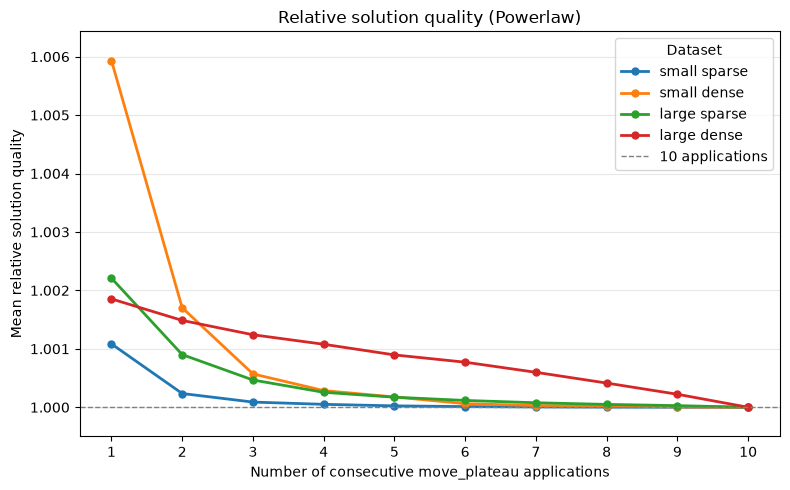

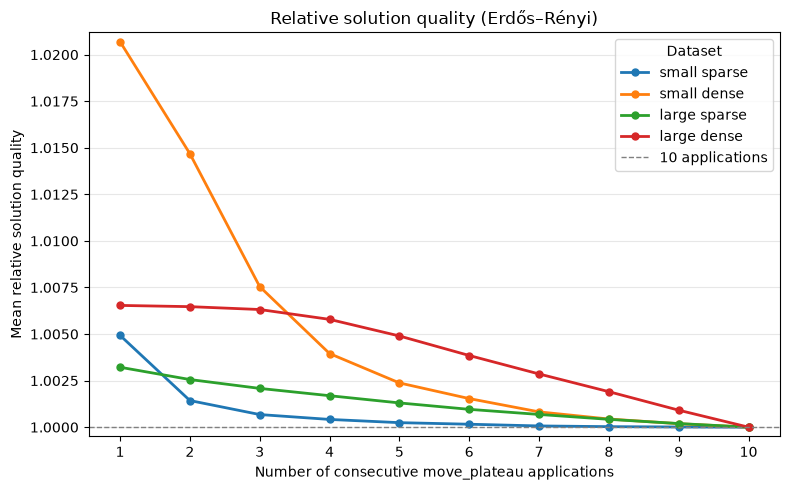

In [7]:
plot_relative_quality(
    relative_quality_summary,
    "powerlaw",
    PLOTS_DIR / "powerlaw_plateau_search_quality.png",
)

plot_relative_quality(
    relative_quality_summary,
    "er",
    PLOTS_DIR / "er_plateau_search_quality.png",
)

## Runtime

For each instance and step number, the start partition of the best-performing run is selected. For this selected start partition, the step runtimes are accumulated separately within every randomized run.

The cumulative runtimes of all runs using the selected start partition are then summed. Finally, these total runtimes are averaged over all instances in the corresponding graph and dataset group.

In [ ]:
trajectory_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "experiment",
    "start_partition",
    "pipeline",
    "zero_gain_factor",
    "run",
]

configuration_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "step_number",
    "experiment",
    "start_partition",
    "pipeline",
    "zero_gain_factor",
]

steps_with_runtime = steps.sort_values(trajectory_keys + ["step_number"]).copy()

steps_with_runtime["cumulative_runtime"] = steps_with_runtime.groupby(trajectory_keys, observed=True, dropna=False)["runtime"].cumsum()

winning_configurations = best_runs[configuration_keys].drop_duplicates()

winning_runtimes = steps_with_runtime.merge(winning_configurations, on=configuration_keys, how="inner")

runtime_per_instance = (
    winning_runtimes
    .groupby(best_run_keys, observed=True, as_index=False)
    .agg(total_cumulative_runtime=("cumulative_runtime", "sum"))
)

runtime_summary = (
    runtime_per_instance
    .groupby(["graph_type", "dataset_group", "step_number"], observed=True, as_index=False)
    .agg(mean_total_runtime=("total_cumulative_runtime", "mean"))
)

runtime_summary

## Runtime development

The figures show the mean cumulative runtime of all randomized runs after each number of consecutive `move_plateau` applications.

In [ ]:
def plot_total_runtime(summary: pd.DataFrame, graph_type: str, output_path: Path | None = None) -> None:
    graph_data = summary[summary["graph_type"] == graph_type].sort_values(["dataset_group", "step_number"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["step_number"],
            group_data["mean_total_runtime"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.set_xlabel("Number of consecutive move_plateau applications")
    ax.set_ylabel("Mean total run time of ten runs (s)")
    ax.set_title(f"Total run time ({GRAPH_TYPE_LABELS[graph_type]})")
    ax.set_xticks(MOVE_STEPS)

    ax.legend(title="Dataset")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

In [ ]:
plot_total_runtime(
    runtime_summary,
    "powerlaw",
    PLOTS_DIR / "powerlaw_plateau_search_runtime.png",
)

plot_total_runtime(
    runtime_summary,
    "er",
    PLOTS_DIR / "er_plateau_search_runtime.png",
)